In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import title
from pyspark.sql.functions import year
from wcwidth import width

from test1 import col

In [125]:
df_sales = pd.read_csv(r"C:\Users\new\Desktop\New folder\car.csv")
df_sales.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [24]:
Seller_type_car = df_sales.groupby('Seller_Type').agg(count_car= ('Car_Name','count'))
Seller_type_car

,count_car
Seller_Type,
Dealer,195
Individual,106


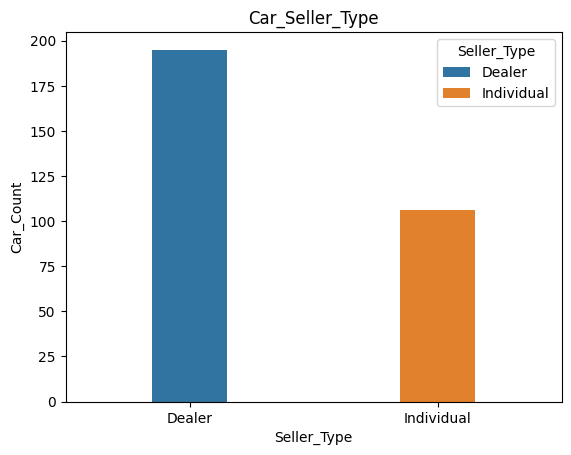

In [82]:
sns.barplot(data= Seller_type_car, x= 'Seller_Type',
            y= 'count_car',
            width=.3,
            hue = 'Seller_Type',
            legend=True,
            )
plt.title('Car_Seller_Type')
plt.xlabel('Seller_Type')
plt.ylabel('Car_Count')
plt.legend(title='Seller_Type')
plt.show()

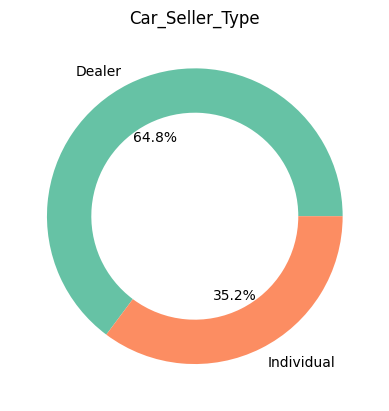

In [80]:
plt.pie(Seller_type_car.count_car,
        labels=Seller_type_car.index,
        autopct='%1.1f%%',
        #shadow=True,
        wedgeprops=dict(width=.3),
        colors = sns.color_palette('Set2',len(Seller_type_car.index))
        )
plt.title('Car_Seller_Type')


plt.show()

In [25]:
sales_car_by_fuel_type = df_sales.groupby(['Fuel_Type']).agg(count_car= ('Car_Name','count'))
sales_car_by_fuel_type

,count_car
Fuel_Type,
CNG,2
Diesel,60
Petrol,239


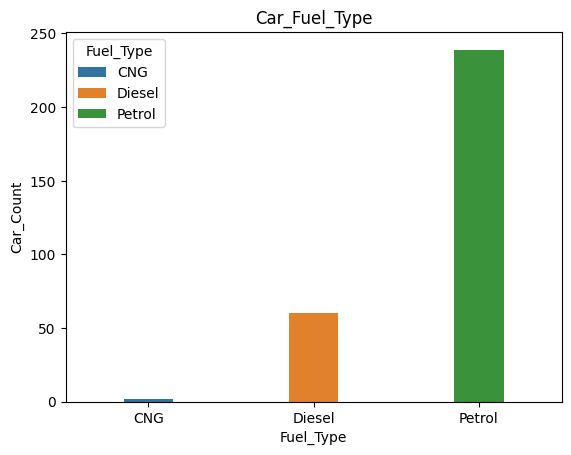

<Figure size 500x500 with 0 Axes>

In [54]:
sns.barplot(data=sales_car_by_fuel_type,
            x= 'Fuel_Type',
            y= 'count_car',
            hue= 'Fuel_Type',
            legend=True,
            width=.3)
plt.title('Car_Fuel_Type')
plt.xlabel('Fuel_Type')
plt.ylabel('Car_Count')
plt.legend(title='Fuel_Type', loc='upper left')
plt.figure(2, figsize= (5,5))
plt.show()

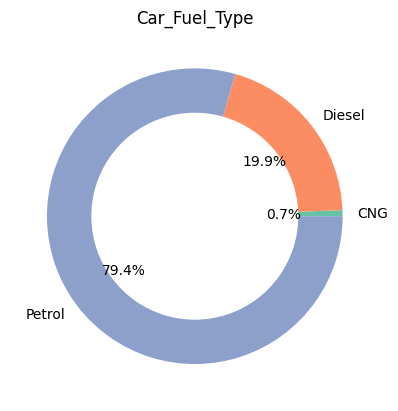

In [87]:
plt.pie(sales_car_by_fuel_type.count_car,
        labels=sales_car_by_fuel_type.index,
        autopct='%1.1f%%',
        wedgeprops=dict(width=.3),
        colors = sns.color_palette('Set2',len(sales_car_by_fuel_type.index)))
plt.title('Car_Fuel_Type')
plt.show()

In [27]:
sales_car_by_transmission = df_sales.groupby('Transmission').agg(count_car= ('Car_Name','count'))
sales_car_by_transmission

,count_car
Transmission,
Automatic,40
Manual,261


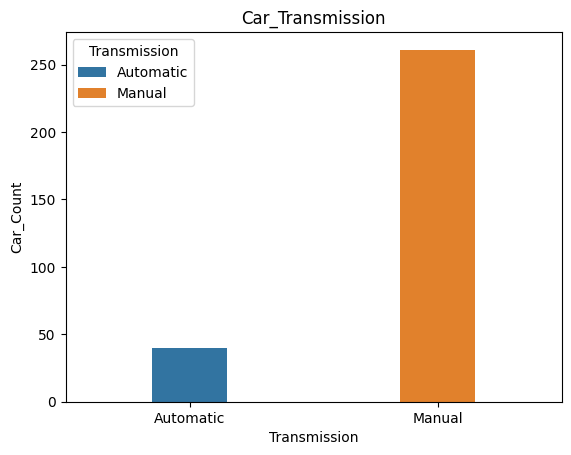

In [58]:
sns.barplot(data=sales_car_by_transmission,x= 'Transmission',
            y= 'count_car',width=.3,
            hue= 'Transmission',
            legend=True )
plt.title('Car_Transmission')
plt.xlabel('Transmission')
plt.ylabel('Car_Count')
plt.legend(title='Transmission')
plt.show()

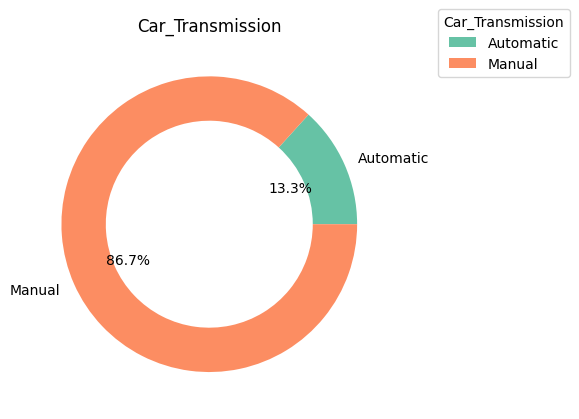

In [102]:
plt.pie(sales_car_by_transmission.count_car,
        labels=sales_car_by_transmission.index,
        autopct='%1.1f%%',
        colors = sns.color_palette('Set2',len(sales_car_by_transmission.index)),
        wedgeprops=dict(width=.3)
        )
plt.title('Car_Transmission')
plt.legend(sales_car_by_transmission.index,
           loc='upper left', bbox_to_anchor=(1.1, 1.1),
           title = 'Car_Transmission')
plt.show()

In [126]:
Price_diffrence =df_sales.groupby('Year').agg(sum_sell_price = ('Selling_Price','sum'),
                                              sum_Present_price = ('Present_Price','sum'),
                                              count_car= ('Car_Name','count')
                                              )
Price_diffrence.head(5)

,sum_sell_price,sum_Present_price,count_car
Year,,,
2003,2.60,10.26,2
2004,1.50,12.35,1
2005,9.95,37.94,4
2006,5.75,36.23,4
2007,0.32,1.33,2


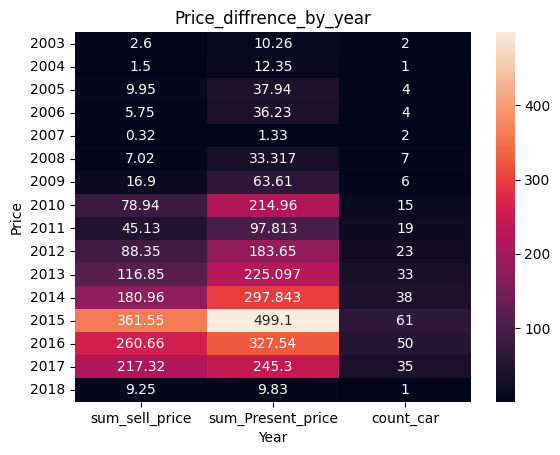

In [127]:
sns.heatmap(data=Price_diffrence,annot=True,fmt='g')
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Price_diffrence_by_year')
plt.show()